# Knowledge Preprocessing — Conversation Thread Chunking

Transforms `data/raw/twcs.csv` (2.8M raw tweets) into `data/knowledge/thread_chunks.csv`
where each row is one complete customer–brand conversation thread, ready for embedding.

**Output schema:**
| column | type | description |
|--------|------|-------------|
| `thread_id` | int | Root tweet ID (customer first-contact) |
| `brand` | str | Author handle of the first brand reply |
| `message_count` | int | Number of tweets in this thread |
| `text` | str | Formatted dialogue: `[Customer]: ...\n[Brand]: ...` |

**Filters applied (in order):**
1. Drop individual tweets with null or empty text before thread construction
2. Drop threads with no brand reply (`message_count == 1` or all-customer)
3. Drop threads whose full text contains fewer than 3 words (too thin to embed)
4. Drop exact duplicate threads (same text content, keep first occurrence)

## 0 — Setup

In [1]:
from collections import deque
from pathlib import Path

import pandas as pd

RAW_CSV   = Path("../data/raw/twcs.csv")
OUT_DIR   = Path("../data/knowledge")
OUT_CSV   = OUT_DIR / "thread_chunks.csv"
MAX_DEPTH = 6   # BFS depth cap per thread
MIN_WORDS = 3   # minimum word count for the full thread text

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Raw CSV : {RAW_CSV}")
print(f"Output  : {OUT_CSV}")

Raw CSV : ../data/raw/twcs.csv
Output  : ../data/knowledge/thread_chunks.csv


## 1 — Load raw CSV

Only the five columns needed for thread reconstruction are loaded.
Tweets with null or empty text are dropped immediately — they carry no signal.

In [2]:
USECOLS = ["tweet_id", "author_id", "inbound", "text", "in_response_to_tweet_id"]

df = pd.read_csv(
    RAW_CSV,
    usecols=USECOLS,
    dtype={"tweet_id": int, "author_id": str, "text": str},
)

df["in_response_to_tweet_id"] = pd.to_numeric(
    df["in_response_to_tweet_id"], errors="coerce"
)
df["inbound"] = df["inbound"].astype(bool)
df["text"]    = df["text"].fillna("").str.strip()

before = len(df)
df = df[df["text"].str.len() > 0]          # drop null / empty text
dropped_empty = before - len(df)

print(f"Rows loaded      : {before:,}")
print(f"Dropped (no text): {dropped_empty:,}")
print(f"Rows kept        : {len(df):,}")
print(f"Inbound          : {df['inbound'].sum():,}  ({df['inbound'].mean():.1%})")
print(f"Outbound         : {(~df['inbound']).sum():,}  ({(~df['inbound']).mean():.1%})")
df.head(3)

Rows loaded      : 2,811,774
Dropped (no text): 0
Rows kept        : 2,811,774
Inbound          : 1,537,843  (54.7%)
Outbound         : 1,273,931  (45.3%)


,tweet_id,author_id,inbound,text,in_response_to_tweet_id
0,1,sprintcare,False,@115712 I understand. I would like to assist y...,3.0
1,2,115712,True,@sprintcare and how do you propose we do that,1.0
2,3,115712,True,@sprintcare I have sent several private messag...,4.0


## 2 — Build adjacency index

- `tweet_by_id` — `{tweet_id → row dict}` for O(1) lookup during BFS
- `children` — `{tweet_id → [child tweet_ids]}` built from `in_response_to_tweet_id`

Roots are inbound tweets with no parent (customer first-contacts).

In [3]:
tweet_by_id = {
    int(row["tweet_id"]): {
        "tweet_id" : int(row["tweet_id"]),
        "author_id": str(row["author_id"]),
        "inbound"  : bool(row["inbound"]),
        "text"     : str(row["text"]),
        "parent"   : row["in_response_to_tweet_id"],
    }
    for _, row in df.iterrows()
}

children: dict[int, list[int]] = {tid: [] for tid in tweet_by_id}
for row in tweet_by_id.values():
    parent = row["parent"]
    if pd.notna(parent):
        pid = int(parent)
        if pid in children:
            children[pid].append(row["tweet_id"])

roots = [
    tid
    for tid, row in tweet_by_id.items()
    if row["inbound"] and pd.isna(row["parent"])
]

print(f"Total tweets : {len(tweet_by_id):,}")
print(f"Root tweets  : {len(roots):,}  (customer first-contacts)")

Total tweets : 2,811,774
Root tweets  : 787,346  (customer first-contacts)


## 3 — BFS thread reconstruction

For each root, walk the `children` map up to `MAX_DEPTH` levels.
Threads with no brand reply are discarded here (first filter pass).

In [4]:
def bfs_thread(root_id: int) -> list[dict]:
    """Return an ordered list of tweet dicts for one conversation thread."""
    messages = []
    queue = deque([(root_id, 0)])
    visited: set[int] = set()
    while queue:
        tid, depth = queue.popleft()
        if tid in visited or depth > MAX_DEPTH:
            continue
        visited.add(tid)
        row = tweet_by_id.get(tid)
        if row is None:
            continue
        messages.append(row)
        for child_id in children.get(tid, []):
            if child_id not in visited:
                queue.append((child_id, depth + 1))
    return messages


records = []
seen_hashes: set[int] = set()   # for dedup without storing full text twice

skipped_no_reply  = 0
skipped_too_short = 0
skipped_duplicate = 0

for root_id in roots:
    messages = bfs_thread(root_id)

    # Filter 1 — must have at least one brand reply
    if len(messages) < 2 or all(m["inbound"] for m in messages):
        skipped_no_reply += 1
        continue

    brand = next((m["author_id"] for m in messages if not m["inbound"]), "unknown")
    lines = [
        f"{'[Customer]' if m['inbound'] else '[Brand]'}: {m['text']}"
        for m in messages
    ]
    text = "\n".join(lines)

    # Filter 2 — minimum word count (count spaces+1, no list allocation)
    if text.count(" ") + 1 < MIN_WORDS:
        skipped_too_short += 1
        continue

    # Filter 3 — exact duplicate (hash only, no second copy of text)
    h = hash(text)
    if h in seen_hashes:
        skipped_duplicate += 1
        continue
    seen_hashes.add(h)

    records.append({
        "thread_id"    : root_id,
        "brand"        : brand,
        "message_count": len(messages),
        "text"         : text,
    })

del seen_hashes   # free the hash set immediately

print(f"Threads kept        : {len(records):,}")
print(f"Skipped (no reply)  : {skipped_no_reply:,}")
print(f"Skipped (< {MIN_WORDS} words) : {skipped_too_short:,}")
print(f"Skipped (duplicate) : {skipped_duplicate:,}")

Threads kept        : 786,128
Skipped (no reply)  : 1,213
Skipped (< 3 words) : 0
Skipped (duplicate) : 5


## 4 — Build final DataFrame

All filters were applied inside the BFS loop. Convert `records` to a DataFrame
and immediately free the list to avoid holding two copies in memory.

In [5]:
chunks = pd.DataFrame(records)
del records   # free the list of dicts — chunks is now the only copy

print(f"Final chunks : {len(chunks):,}")
chunks.head(3)

Final chunks : 786,128


,thread_id,brand,message_count,text
0,8,sprintcare,10,[Customer]: @sprintcare is the worst customer ...
1,18,sprintcare,8,[Customer]: @115714 y’all lie about your “grea...
2,20,sprintcare,2,[Customer]: @115714 whenever I contact custome...


## 5 — Quality statistics

In [6]:
print("=== Thread length distribution (messages) ===")
print(chunks["message_count"].describe().astype(int).to_string())
print()
print("=== Top 15 brands by thread count ===")
print(chunks["brand"].value_counts().head(15).to_string())
print()
print(f"Unique brands   : {chunks['brand'].nunique():,}")
print(f"Total threads   : {len(chunks):,}")
print(f"Avg word count  : {chunks['text'].str.split().str.len().mean():.0f} words")
print(f"Avg text length : {chunks['text'].str.len().mean():.0f} chars")

=== Thread length distribution (messages) ===
count    786128
mean          3
std           3
min           2
25%           2
50%           2
75%           4
max         917

=== Top 15 brands by thread count ===
brand
AmazonHelp         81224
AppleSupport       80073
Uber_Support       41701
SpotifyCares       28144
AmericanAir        25878
Delta              25866
comcastcares       23740
TMobileHelp        22383
SouthwestAir       21362
Ask_Spectrum       18268
Tesco              16491
British_Airways    16285
UPSHelp            15132
hulu_support       14785
VirginTrains       14420

Unique brands   : 108
Total threads   : 786,128
Avg word count  : 68 words
Avg text length : 413 chars


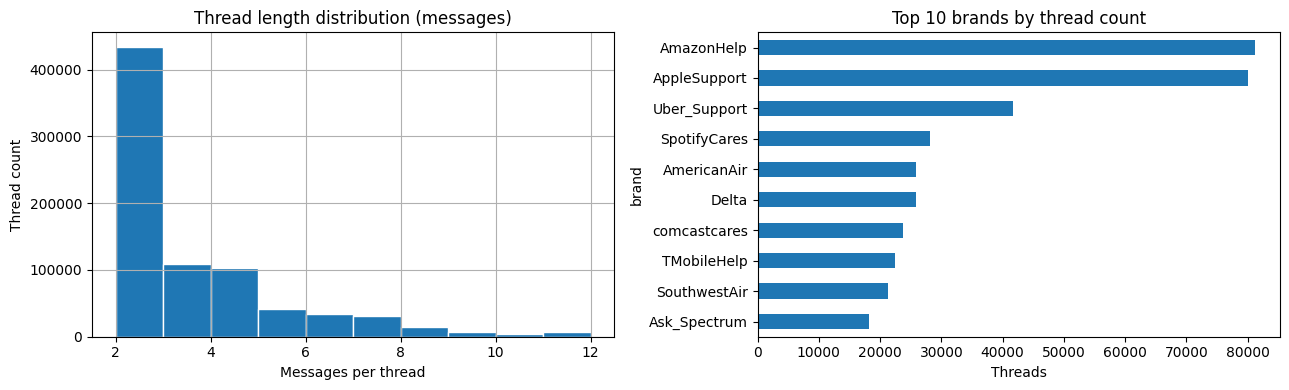

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Thread length histogram
chunks["message_count"].clip(upper=12).hist(
    bins=range(2, 13), ax=axes[0], edgecolor="white"
)
axes[0].set_title("Thread length distribution (messages)")
axes[0].set_xlabel("Messages per thread")
axes[0].set_ylabel("Thread count")

# Top 10 brands bar chart
top_brands = chunks["brand"].value_counts().head(10)
top_brands.plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 10 brands by thread count")
axes[1].set_xlabel("Threads")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 6 — Save to `data/knowledge/thread_chunks.csv`

In [8]:
chunks.to_csv(OUT_CSV, index=False)
print(f"Saved {len(chunks):,} thread chunks → {OUT_CSV}")
print(f"File size: {OUT_CSV.stat().st_size / 1_000_000:.1f} MB")
chunks.head(3)

Saved 786,128 thread chunks → ../data/knowledge/thread_chunks.csv
File size: 348.6 MB


,thread_id,brand,message_count,text
0,8,sprintcare,10,[Customer]: @sprintcare is the worst customer ...
1,18,sprintcare,8,[Customer]: @115714 y’all lie about your “grea...
2,20,sprintcare,2,[Customer]: @115714 whenever I contact custome...


## 7 — Verify

Spot-check a sample thread to confirm formatting and filtering are correct.

In [9]:
sample = chunks.sample(1, random_state=42).iloc[0]
print(f"thread_id    : {sample['thread_id']}")
print(f"brand        : {sample['brand']}")
print(f"message_count: {sample['message_count']}")
print(f"word count   : {len(sample['text'].split())}")
print()
print(sample["text"])

thread_id    : 1000560
brand        : hulu_support
message_count: 2
word count   : 47

[Customer]: @115940 this exchange however truly has me leaning towards dropping you. Who pays for a service they can't use?
[Brand]: @130105 Oh no! We're so sorry to hear this—we'll be sharing this experience. What device are you using? We'd love to see if we can help!
